## 4. 深度學習模型：5層一維卷積神經網路 (1D-CNN Model)
建立 5 層一維卷積層 (Conv1D) 之神經網路模型，同時輸入 **雙通道 (Drive End 驅動端 + Fan End 風扇端)** 震動數據。透過小捲積核與最大池化層自動提取特徵，總參數目少於邏輯回歸模型，卻具備極高的故障特徵辨識能力。

In [8]:
# ===== 1. 匯入系統與深度學習核心模組 =====
# 載入數據解包 (pickle)、TensorFlow/Keras 框架與卷積層、池化層、Dropout 等組件
import pickle
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint


## 1. 載入預處理數據集 (Data Loading)
讀取經由 `run_data_prep.py` 打包完成之 `./data/ABCD_Datasets.pickle` 數據集，包含 10 種軸承故障類別在不同馬力負載下的加速度震動訊號。

In [9]:
# ===== 2. 讀取 pickle 數據檔並提取類別 D =====
pfile = r"./data/ABCD_Datasets.pickle"
with (open(pfile, "rb")) as openfile:
    while True:
        try:
            ABCD_Datasets = pickle.load(openfile)
        except EOFError:
            break

# 提取混和不同馬力負載之類別 D 訓練與測試資料
X_train_D = ABCD_Datasets["train_datasets"]["D"]
Y_train_D = ABCD_Datasets["train_labels"]["D"]
X_test_D = ABCD_Datasets["test_datasets"]["D"]
Y_test_D = ABCD_Datasets["test_labels"]["D"]


### 1.5 原始軸承震動訊號波形展示 (Raw Signal Waveforms)
抽取 10 種軸承狀態（包含正常 baseline、內圈故障、外圈故障與滾珠故障）在驅動端 (Drive End) 加速度計記錄的 2,048 點時域震動波形進行對比。

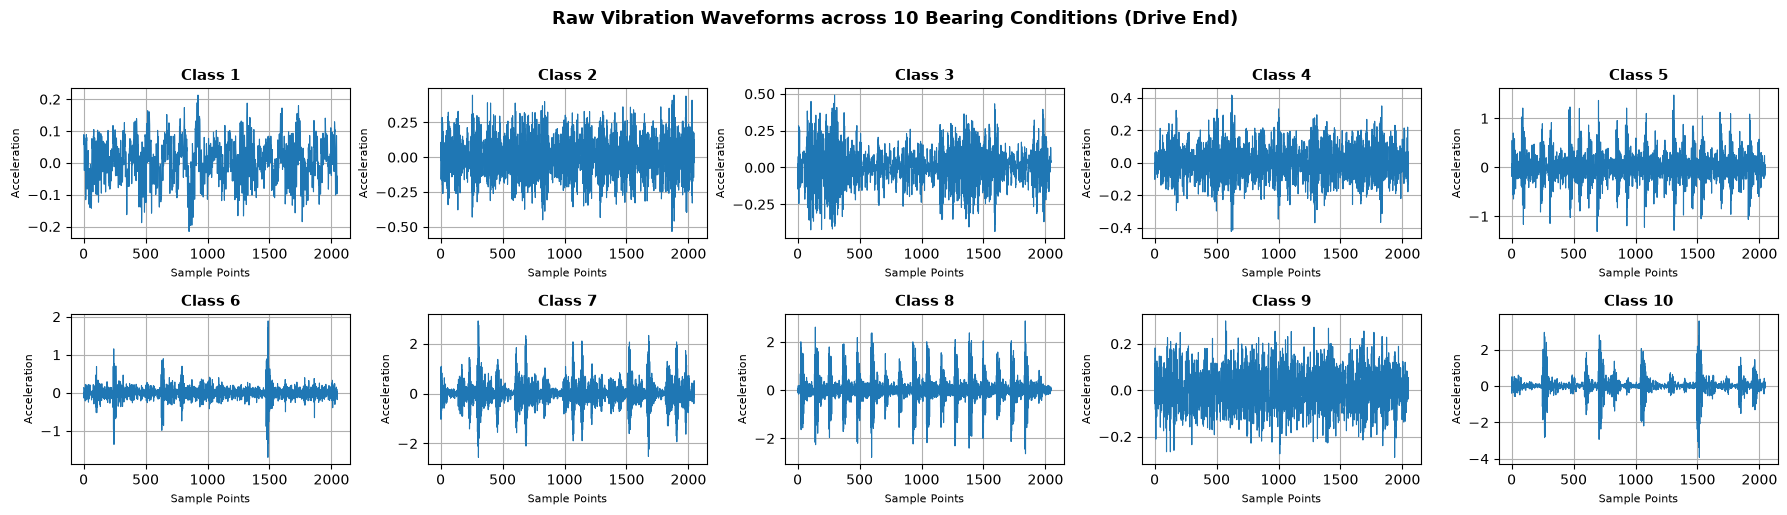

In [10]:
# ===== 1.5 繪製 10 種軸承狀態的原始震動訊號波形 =====
import numpy as np
import matplotlib.pyplot as plt

plt.rc('axes', grid=True)
plt.figure(figsize=(18, 5))

for faulttype in range(1, 11):
    idxTF = (Y_train_D == faulttype).flatten()
    matching_indices = np.where(idxTF)[0]
    if len(matching_indices) > 0:
        idxNo = matching_indices[0]
        plt.subplot(2, 5, faulttype)
        plt.plot(X_train_D[idxNo][:2048, 0], color='#1f77b4', linewidth=0.8)
        plt.title(f"Class {faulttype}", fontsize=11, fontweight='bold')
        plt.xlabel("Sample Points", fontsize=8)
        plt.ylabel("Acceleration", fontsize=8)

plt.suptitle("Raw Vibration Waveforms across 10 Bearing Conditions (Drive End)", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('1DCNN_raw_waveforms.png', dpi=300, bbox_inches='tight')
plt.show()


## 2. 標籤單熱編碼與數據切分 (One-Hot Encoding & Dataset Splitting)
將 10 種分類標籤轉為 One-Hot 矩陣，並將數據集切分為 **訓練集 (Training Set)**、**驗證集 (Validation Set, 2,000 筆)** 與 **測試集 (Test Set)**。

In [11]:
# ===== 3. 標籤轉換與訓練/驗證集分割 =====
num_classes = 10  # 10 種軸承健康/故障狀態
# 標籤值減 1 以對齊 0-indexed 分類編號，並進行 One-Hot 編碼
Y_train_D_hot = keras.utils.to_categorical(Y_train_D - 1, num_classes)
Y_test_D_hot = keras.utils.to_categorical(Y_test_D - 1, num_classes)

# 從訓練集中切出前 2000 筆作為驗證集 (Validation Set)
(X_train, X_valid) = X_train_D[2000:], X_train_D[:2000]
(Y_train, Y_valid) = Y_train_D_hot[2000:], Y_train_D_hot[:2000]
X_test = X_test_D
Y_test = Y_test_D_hot

# 輸出數據維度資訊
print('訓練集輸入維度 (x_train shape):', X_train.shape)
print(X_train.shape[0], '筆訓練樣本 (train samples)')
print(X_test.shape[0], '筆測試樣本 (test samples)')
print(X_valid.shape[0], '筆驗證樣本 (validation samples)')


訓練集輸入維度 (x_train shape): (17800, 2048, 2)
17800 筆訓練樣本 (train samples)
750 筆測試樣本 (test samples)
2000 筆驗證樣本 (validation samples)


## 3. 基線模型：邏輯回歸 (Baseline Model: Logistic Regression)
建立單層全連接之邏輯回歸模型作為基準對照組，僅輸入單通道 (Drive End 驅動端) 震動數據。

In [12]:
# ===== 4. 邏輯回歸 Baseline 模型建構與訓練 =====
CNNch = 1  # 僅使用單通道 (DE 驅動端加速度計)
ne = 10     # 訓練輪數 (Epochs)

# 建立簡單模型：Flatten 攤平特徵 -> 10 類別 Softmax 全連接層
modelLog = Sequential()
modelLog.add(Flatten(input_shape=(2048, CNNch)))
modelLog.add(Dense(10, activation='softmax'))

modelLog.summary()  # 輸出模型參數結構

# 模型編譯：交叉熵損失函數 + RMSprop 優化器
modelLog.compile(loss='categorical_crossentropy', optimizer='rmsprop', metrics=['accuracy'])

# 開始訓練基線模型
hist = modelLog.fit(X_train[:, :, 0:CNNch], Y_train, batch_size=32, epochs=ne,
          validation_data=(X_valid[:, :, 0:CNNch], Y_valid), 
          verbose=1, shuffle=True)

# 評估基線模型於測試集之準確率
score = modelLog.evaluate(X_test[:, :, 0:CNNch], Y_test, verbose=0)
print('\n', 'Logistic Regression 測試集準確率 (Test accuracy):', score[1])


d:\PYTHON\1DCNN-master\venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        20,490 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,490 (80.04 KB)

 Trainable params: 20,490 (80.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
557/557 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.2029 - loss: 2.3641 - val_accuracy: 0.1850 - val_loss: 2.3441
Epoch 2/10
557/557 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2495 - loss: 2.2468 - val_accuracy: 0.2130 - val_loss: 2.3379
Epoch 3/10
557/557 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2917 - loss: 2.1823 - val_accuracy: 0.2160 - val_loss: 2.3435
Epoch 4/10
557/557 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3218 - loss: 2.1376 - val_accuracy: 0.2360 - val_loss: 2.3250
Epoch 5/10
557/557 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3471 - loss: 2.0977 - val_accuracy: 0.2520 - val_loss: 2.3112
Epoch 6/10
557/557 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3640 - loss: 2.0682 - val_accuracy: 0.2445 - val_loss: 2.2902
Epoch 7/10
557/557 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3662 - loss: 2.0442 - val_accuracy: 0.2525 - val_loss: 2.2772
Epoch 8/10
557/557 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3784 - loss: 2.0199 - val_accuracy: 0.

## 4. 深度學習模型：5層一維卷積神經網路 (1D-CNN Model)
建立 5 層一維卷積層 (Conv1D) 之神經網路模型，同時輸入 **雙通道 (Drive End 驅動端 + Fan End 風扇端)** 震動數據。透過小捲積核與最大池化層自動提取特徵，總參數目少於邏輯回歸模型，卻具備極高的故障特徵辨識能力。

In [13]:
# ===== 5. 5層 1D-CNN 深度學習模型建構、訓練與評估 =====
CNNch = 2  # 使用雙通道 (DE 驅動端 + FE 風扇端加速度計數據)
ne = 10    # 訓練輪數 (Epochs)

modelC2 = Sequential()
# 第 1 層：一維卷積 (16 個 Filters, 大 Kernel Size=64, Strides=16) + 最大池化
modelC2.add(Conv1D(filters=16, kernel_size=64, strides=16, padding='same', activation='relu', input_shape=(2048, CNNch)))
modelC2.add(MaxPooling1D(pool_size=2))

# 第 2 層：一維卷積 (16 個 Filters, Kernel Size=3) + 最大池化
modelC2.add(Conv1D(filters=16, kernel_size=3, strides=1, padding='same', activation='relu'))
modelC2.add(MaxPooling1D(pool_size=2))

# 第 3 層：一維卷積 (32 個 Filters, Kernel Size=3) + 最大池化 + Dropout(0.2)
modelC2.add(Conv1D(filters=32, kernel_size=3, strides=1, padding='same', activation='relu'))
modelC2.add(MaxPooling1D(pool_size=2))
modelC2.add(Dropout(0.2))

# 第 4 層：一維卷積 (32 個 Filters, Kernel Size=3) + 最大池化 + Dropout(0.2)
modelC2.add(Conv1D(filters=32, kernel_size=3, strides=1, padding='same', activation='relu'))
modelC2.add(MaxPooling1D(pool_size=2))
modelC2.add(Dropout(0.2))

# 第 5 層：一維卷積 (32 個 Filters, Kernel Size=3) + 最大池化
modelC2.add(Conv1D(filters=32, kernel_size=3, strides=1, padding='same', activation='relu'))
modelC2.add(MaxPooling1D(pool_size=2))

# 特徵攤平與全連接分類層
modelC2.add(Flatten())
modelC2.add(Dense(50, activation='relu'))
modelC2.add(Dropout(0.2))
modelC2.add(Dense(10, activation='softmax'))

modelC2.summary()  # 顯示 1D-CNN 結構摘要

# 編譯模型
modelC2.compile(loss='categorical_crossentropy', optimizer='rmsprop', metrics=['accuracy'])

# 設定 ModelCheckpoint 保存驗證集表現最佳之模型權重 (.weights.h5)
checkpointer = ModelCheckpoint(filepath='CNNC2.weights.best.weights.h5', verbose=1, save_best_only=True, save_weights_only=True)

# 開始訓練 1D-CNN
hist = modelC2.fit(X_train[:, :, 0:CNNch], Y_train, batch_size=32, epochs=ne,
          validation_data=(X_valid[:, :, 0:CNNch], Y_valid), callbacks=[checkpointer], 
          verbose=1, shuffle=True)

# 載入訓練過程中最優驗證集準確率之權重檔
modelC2.load_weights('CNNC2.weights.best.weights.h5')

# 評估並輸出最終測試集、訓練集與驗證集之準率
score = modelC2.evaluate(X_test[:, :, 0:CNNch], Y_test, verbose=0)
print('\n', 'CNN 測試集準確率 (Test accuracy):', score[1])

score = modelC2.evaluate(X_train[:, :, 0:CNNch], Y_train, verbose=0)
print('\n', 'CNN 訓練集準確率 (Train accuracy):', score[1])

score = modelC2.evaluate(X_valid[:, :, 0:CNNch], Y_valid, verbose=0)
print('\n', 'CNN 驗證集準確率 (Validation accuracy):', score[1])


d:\PYTHON\1DCNN-master\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 128, 16)        │         2,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 64, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 64, 16)         │           784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 32, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 32, 32)         │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 16, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 16, 32)         │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 8, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 8, 32)          │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 4, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │         6,450 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,584 (68.69 KB)

 Trainable params: 17,584 (68.69 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
554/557 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7259 - loss: 0.7277
Epoch 1: val_loss improved from None to 0.05780, saving model to CNNC2.weights.best.weights.h5

Epoch 1: finished saving model to CNNC2.weights.best.weights.h5
557/557 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.7268 - loss: 0.7254 - val_accuracy: 0.9885 - val_loss: 0.0578
Epoch 2/10
552/557 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9766 - loss: 0.0783
Epoch 2: val_loss improved from 0.05780 to 0.01332, saving model to CNNC2.weights.best.weights.h5

Epoch 2: finished saving model to CNNC2.weights.best.weights.h5
557/557 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9767 - loss: 0.0778 - val_accuracy: 0.9955 - val_loss: 0.0133
Epoch 3/10
556/557 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9899 - loss: 0.0316
Epoch 3: val_loss improved from 0.01332 to 0.00108, saving model to CNNC2.weights.best.weights.h5

Epoch 3: finished saving model to CNNC2.weights.best.weights.h5
557/557 ━━━━━━━━━━━━━━

## 5. 結果可視化 (Result Visualization)
繪製 1D-CNN 模型訓練過程的 **Loss / Accuracy 變化歷史曲線**，以及測試集之 **混淆矩陣 (Confusion Matrix)** 熱力圖。

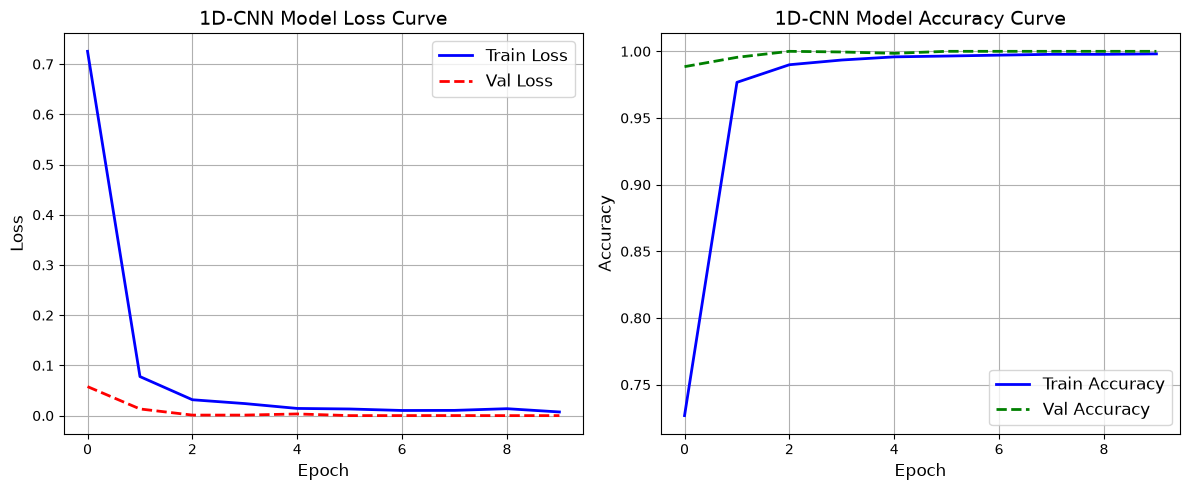

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


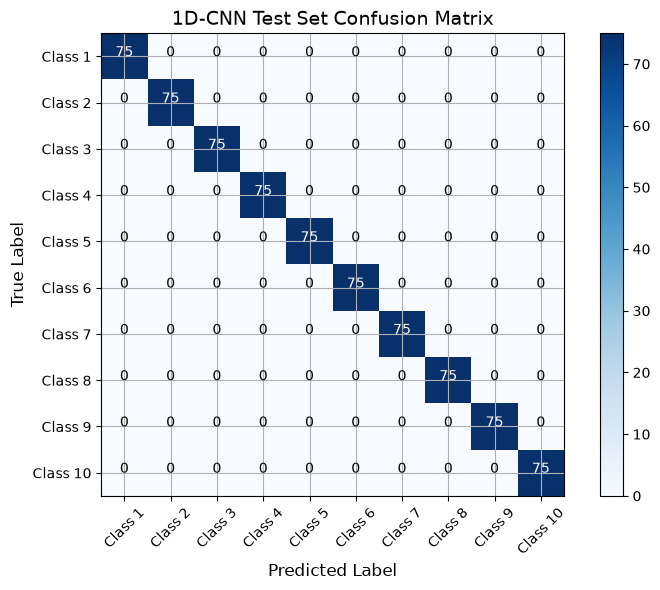

In [14]:
# ===== 6. 繪製 Loss / Accuracy 歷史訓練曲線與測試集混淆矩陣 =====
import numpy as np
import matplotlib.pyplot as plt

# 1. 繪製 Loss & Accuracy 歷史曲線
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(hist.history['loss'], label='Train Loss', color='blue', linewidth=2)
plt.plot(hist.history['val_loss'], label='Val Loss', color='red', linestyle='--', linewidth=2)
plt.title('1D-CNN Model Loss Curve', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(hist.history['accuracy'], label='Train Accuracy', color='blue', linewidth=2)
plt.plot(hist.history['val_accuracy'], label='Val Accuracy', color='green', linestyle='--', linewidth=2)
plt.title('1D-CNN Model Accuracy Curve', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True)

plt.tight_layout()
plt.savefig('1DCNN_training_history.png', dpi=300)
plt.show()

# 2. 計算與繪製測試集混淆矩陣 (Confusion Matrix)
Y_pred = modelC2.predict(X_test[:, :, 0:CNNch])
y_pred_classes = np.argmax(Y_pred, axis=1)
y_true_classes = np.argmax(Y_test, axis=1)

cm = np.zeros((num_classes, num_classes), dtype=int)
for t, p in zip(y_true_classes, y_pred_classes):
    cm[t, p] += 1

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('1D-CNN Test Set Confusion Matrix', fontsize=14)
plt.colorbar()
tick_marks = np.arange(num_classes)
class_names = [f'Class {i+1}' for i in range(num_classes)]
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('1DCNN_confusion_matrix.png', dpi=300)
plt.show()


## 6. 互動式智能故障診斷控制面板 (Interactive Fault Diagnosis Panel)
透過下方互動下拉選單選擇測試樣本（或選擇隨機抽樣），點擊 **「🔍 執行 1D-CNN 故障智能診斷」** 按鈕，系統將自動繪製該樣本的雙通道即時震動波形，並輸出包含故障部位、損傷程度與維護建議之診斷報告。

In [15]:
# ===== 6. 互動式智能故障診斷面板 (ipywidgets) =====
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
import matplotlib.pyplot as plt
import numpy as np

class_info_widget = [
    {"Class_ID": 1, "Name": "Normal Baseline", "Location": "無故障 (Normal)", "Severity": "0.000 (正常健康)", "Recommendation": "軸承狀態良好，請繼續保持定期監測與正常潤滑。"},
    {"Class_ID": 2, "Name": "0.007_Inner_Race", "Location": "內圈故障 (Inner Race)", "Severity": "0.007 英吋 (輕微點蝕)", "Recommendation": "檢測到微小內圈點蝕，建議安排於下次例行維護時複查。"},
    {"Class_ID": 3, "Name": "0.007_Ball", "Location": "滾珠故障 (Ball)", "Severity": "0.007 英吋 (輕微點蝕)", "Recommendation": "檢測到微小滾珠點蝕，請補充潤滑油脂並密切關注振幅變化。"},
    {"Class_ID": 4, "Name": "0.007_Outer_Race", "Location": "外圈故障 (Outer Race)", "Severity": "0.007 英吋 (輕微點蝕)", "Recommendation": "檢測到微小外圈點蝕，建議持續記錄高頻震動趨勢。"},
    {"Class_ID": 5, "Name": "0.014_Inner_Race", "Location": "內圈故障 (Inner Race)", "Severity": "0.014 英吋 (中度損壞)", "Recommendation": "檢測到中度內圈損傷，建議準備備用軸承零件並排定替換計劃。"},
    {"Class_ID": 6, "Name": "0.014_Ball", "Location": "滾珠故障 (Ball)", "Severity": "0.014 英吋 (中度損壞)", "Recommendation": "檢測到中度滾珠損傷，請注意軸承運轉溫度，防範卡死風險。"},
    {"Class_ID": 7, "Name": "0.014_Outer_Race", "Location": "外圈故障 (Outer Race)", "Severity": "0.014 英吋 (中度損壞)", "Recommendation": "檢測到中度外圈損傷，請檢查機台安裝基座與對心狀況。"},
    {"Class_ID": 8, "Name": "0.021_Inner_Race", "Location": "內圈故障 (Inner Race)", "Severity": "0.021 英吋 (重度剝落)", "Recommendation": "【警告】檢測到嚴重內圈剝落，請儘速安排計劃性停機更換軸承！"},
    {"Class_ID": 9, "Name": "0.021_Ball", "Location": "滾珠故障 (Ball)", "Severity": "0.021 英吋 (重度破損)", "Recommendation": "【警告】檢測到嚴重滾珠破損，極易引發機台劇烈震動，建議立即檢修！"},
    {"Class_ID": 10, "Name": "0.021_Outer_Race", "Location": "外圈故障 (Outer Race)", "Severity": "0.021 英吋 (重度裂化)", "Recommendation": "【警告】檢測到嚴重外圈裂化剝落，請立即切換備用機並進行關機檢修！"}
]

# 建立選單選項 (包含隨機與前 50 筆樣本選項)
dropdown_options = [("🎲 隨機抽樣 (Random Sample)", -1)]
for i in range(min(100, len(X_test))):
    t_label = int(Y_test_D[i][0])
    c_name = class_info_widget[t_label - 1]["Name"]
    dropdown_options.append((f"樣本 #{i+1:03d} (真實 Class {t_label}: {c_name})", i))

sample_select = widgets.Dropdown(
    options=dropdown_options,
    value=-1,
    description='選擇測試樣本:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='520px')
)

predict_button = widgets.Button(
    description='🔍 執行 1D-CNN 故障智能診斷',
    button_style='primary',
    icon='search',
    layout=widgets.Layout(width='280px', height='38px')
)

output_panel = widgets.Output()

def on_predict_button_clicked(b):
    with output_panel:
        clear_output(wait=True)
        selected_idx = sample_select.value
        if selected_idx == -1:
            selected_idx = np.random.randint(0, len(X_test))
            print(f"🎲 已隨機選取測試集樣本 #{selected_idx+1:03d} ...\n")
        
        sample_signal = X_test[selected_idx]
        true_label = int(Y_test_D[selected_idx][0])
        
        sample_input = np.expand_dims(sample_signal, axis=0)
        preds = modelC2.predict(sample_input, verbose=0)[0]
        pred_class_idx = int(np.argmax(preds))
        confidence = float(preds[pred_class_idx]) * 100
        info = class_info_widget[pred_class_idx]
        
        plt.figure(figsize=(10, 3))
        plt.plot(sample_signal[:, 0], color='#1f77b4', label='Drive End (DE)', linewidth=1)
        plt.plot(sample_signal[:, 1], color='#ff7f0e', label='Fan End (FE)', linewidth=1, alpha=0.7)
        plt.title(f"Sample #{selected_idx+1:03d} Real-time Vibration Signal Waveform", fontsize=12, fontweight='bold')
        plt.xlabel("Sample Points (2048 Points)", fontsize=10)
        plt.ylabel("Acceleration", fontsize=10)
        plt.legend(loc='upper right')
        plt.grid(True)
        plt.tight_layout()
        plt.show()
        
        status_color = "#28a745" if info["Class_ID"] == 1 else ("#d97706" if "0.007" in info["Name"] else "#dc3545")
        report_html = f"""
        <div style="border: 2px solid {status_color}; padding: 15px; border-radius: 8px; background-color: #ffffff; font-family: Microsoft JhengHei, Arial; margin-top: 10px;">
            <h3 style="color: {status_color}; margin-top: 0;">🛠️ 1D-CNN 軸承故障智能診斷報告 (Diagnostic Report)</h3>
            <table style="width: 100%; font-size: 14px; border-collapse: collapse;">
                <tr><td style="width: 25%; font-weight: bold; padding: 5px;">測試樣本號 (Sample ID):</td><td>#{selected_idx+1:03d}</td></tr>
                <tr><td style="font-weight: bold; padding: 5px;">真實標籤 (True Label):</td><td>Class {true_label} ({class_info_widget[true_label-1]['Name']})</td></tr>
                <tr><td style="font-weight: bold; padding: 5px;">預測類別 (Predicted Class):</td><td><b style="font-size: 16px;">Class {info['Class_ID']} ({info['Name']})</b></td></tr>
                <tr><td style="font-weight: bold; padding: 5px;">診斷置信度 (Confidence):</td><td><b style="color: #0056b3; font-size: 16px;">{confidence:.2f}%</b></td></tr>
                <tr><td style="font-weight: bold; padding: 5px;">故障部位 (Location):</td><td>{info['Location']}</td></tr>
                <tr><td style="font-weight: bold; padding: 5px;">損傷程度 (Severity):</td><td>{info['Severity']}</td></tr>
                <tr><td style="font-weight: bold; padding: 5px;">工廠維護建議 (Action):</td><td style="color: {status_color}; font-weight: bold;">{info['Recommendation']}</td></tr>
            </table>
        </div>
        """
        display(HTML(report_html))

predict_button.on_click(on_predict_button_clicked)

ui_box = widgets.VBox([
    widgets.HTML("<h3 style='color: #1e3a8a;'>🎛️ 1D-CNN 軸承故障互動預測控制面板</h3>"),
    widgets.HBox([sample_select, predict_button]),
    output_panel
])

display(ui_box)
